# W03 · 表格法：Q-Learning 与 SARSA

> 阶段一第 3 周。W01 用动态规划「精确求解」了 MDP——但那需要知道转移概率。
> 本周丢掉这个假设：**只通过与环境交互采样**来学习价值函数，
> 这就是时序差分（TD）学习，也是所有现代深度 RL 算法的思想源头。

## 学习目标

1. 说清 TD 学习与动态规划、蒙特卡洛方法的区别（bootstrapping + sampling）；
2. 写出并推导 Q-Learning 与 SARSA 的更新公式，指出二者在目标值上的唯一差别；
3. 在 FrozenLake-v1 上从零实现两个算法（只用 numpy），并画出成功率曲线；
4. 理解 $\varepsilon$-greedy 探索与衰减策略，会调学习率与折扣因子；
5. 解释为什么 Q-Learning 是 off-policy 而 SARSA 是 on-policy。

**先修要求**：W01（Bellman 方程）、W02（Gymnasium API）。预计用时 3 小时。

## 1. 从 DP 到 TD：把「期望」换成「采样」

W01 的策略评估需要遍历所有 $s'$ 并乘以 $p(s'|s,a)$。现实中我们只有一条条轨迹样本。
TD 学习的核心思想：用**单步采样**代替期望，用**小步长**平滑噪声：

$$V(S_t) \leftarrow V(S_t) + \alpha \big[ \underbrace{R_{t+1} + \gamma V(S_{t+1})}_{\text{TD 目标}} - V(S_t) \big]$$

方括号里叫 **TD 误差** $\delta_t$——「实际看到的」与「原来以为的」之间的差距。
直觉类比：天气预报。DP 像用气候模型精确推演；TD 像每天看实际天气微调明天的预测。

TD 兼具两个特性：

- **Sampling**（像蒙特卡洛）：不需要环境模型，从经验中学；
- **Bootstrapping**（像 DP）：用当前的价值估计去更新价值估计，不必等回合结束。

三大方法对比：

| | 需要模型 | 等到回合结束 | 自举 |
|---|---|---|---|
| 动态规划 | ✅ | — | ✅ |
| 蒙特卡洛 | ❌ | ✅ | ❌ |
| 时序差分 | ❌ | ❌ | ✅ |

## 2. Q-Learning 与 SARSA：一字之差，on/off 之别

维护动作价值表 $Q(s,a)$，两者更新式几乎一样：

**SARSA**（on-policy）——用行为策略**实际采取**的下一动作 $A_{t+1}$：
$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\big[R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t,A_t)\big]$$
名字来自五元组 $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$。

**Q-Learning**（off-policy）——直接用下一状态的**最大** $Q$ 值：
$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\big[R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t,A_t)\big]$$

差别只在 TD 目标：SARSA 评估的是「我实际在执行的（含探索的）策略」，
Q-Learning 评估的是「纯贪心策略」——不管我实际怎么走，目标都是最优策略的值。
回忆 W01 第 6 节：学的就是练的 → on-policy（SARSA）；学的是另一套 → off-policy（Q-Learning）。

**行为后果**（经典例子 CliffWalking）：Q-Learning 学到贴着悬崖的最短路（探索时会掉下去），
SARSA 学到绕开悬崖的安全路——因为它把「探索时可能手滑」也算进了价值里。

**探索**：两者训练时都用 $\varepsilon$-greedy：以 $\varepsilon$ 概率随机动作，否则取 $\arg\max_a Q(s,a)$。
训练后期把 $\varepsilon$ 衰减到接近 0，让策略逐渐「定型」。

## 3. 实验环境：FrozenLake-v1

4×4 冰湖网格：从起点 S 走到礼物 G，不能掉进冰洞 H。
动作 4 个（左/下/右/上），到达 G 得 +1，其余 0（**稀疏奖励**）。

关键参数 `is_slippery=True`：冰面打滑，执行动作后**等概率**滑向意图方向两侧的三个方向——
转移是随机的，这让「背路线」失效，必须学一个对滑动鲁棒的策略。
正因为随机性，最优策略的成功率也不是 100%。

In [1]:
import gymnasium as gym
import numpy as np

env = gym.make("FrozenLake-v1", is_slippery=True)
print("地图（S起点 F冰面 H冰洞 G礼物）：")
print(env.unwrapped.desc.astype(str))
print("状态数:", env.observation_space.n, " 动作数:", env.action_space.n)

# 感受一下打滑：固定起点和动作，多次采样下一状态
from collections import Counter
counts = Counter()
for i in range(200):
    env.reset(seed=i)
    ns, r, term, trunc, _ = env.step(1)  # 动作 1 = 向下
    counts[ns] += 1
print("\n从状态 0 执行'向下'200 次的下一状态分布:", dict(counts))
print("→ 意图向下，却可能滑到右侧（状态 1），这就是随机转移")
env.close()

地图（S起点 F冰面 H冰洞 G礼物）：
[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]
状态数: 16  动作数: 4

从状态 0 执行'向下'200 次的下一状态分布: {0: 62, 1: 70, 4: 68}
→ 意图向下，却可能滑到右侧（状态 1），这就是随机转移


## 4. 从零实现 Q-Learning

下面是一个完整但极简的 Q-Learning：Q 表就是 `(16, 4)` 的 numpy 数组。
注意三个超参数：学习率 $\alpha$、折扣 $\gamma$、探索率 $\varepsilon$（指数衰减）。

In [2]:
def make_epsilon_schedule(eps_start=1.0, eps_end=0.05, decay=0.9995):
    # 指数衰减：ε ← max(ε_end, ε·decay)
    eps = eps_start
    while True:
        yield eps
        eps = max(eps_end, eps * decay)

def train_q_learning(env, n_episodes=8000, alpha=0.1, gamma=0.99, seed=0):
    n_s, n_a = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_s, n_a))
    rng = np.random.default_rng(seed)
    eps_gen = make_epsilon_schedule()
    success_hist = []                      # 每回合是否拿到礼物

    for ep in range(n_episodes):
        eps = next(eps_gen)
        obs, _ = env.reset(seed=seed * 100_000 + ep)
        terminated = truncated = False
        while not (terminated or truncated):
            if rng.random() < eps:         # ε-greedy 探索
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[obs]))
            nobs, r, terminated, truncated, _ = env.step(action)
            # —— Q-Learning 核心更新：用 max_a Q(s', a) 作 TD 目标 ——
            best_next = 0.0 if terminated else np.max(Q[nobs])
            td_target = r + gamma * best_next
            Q[obs, action] += alpha * (td_target - Q[obs, action])
            obs = nobs
        success_hist.append(float(r > 0))  # 只有到达 G 才有 r=1
    return Q, np.array(success_hist)

env = gym.make("FrozenLake-v1", is_slippery=True)
Q_ql, succ_ql = train_q_learning(env)
env.close()
print(f"Q-Learning 训练完成，后 1000 回合成功率: {succ_ql[-1000:].mean():.2%}")

Q-Learning 训练完成，后 1000 回合成功率: 54.70%


## 5. SARSA：只改一行更新目标

SARSA 需要在步进**之前**就选好 $A_{t+1}$（用同一个 $\varepsilon$-greedy 策略），
然后用 $Q(S_{t+1}, A_{t+1})$ 而非 $\max_a Q(S_{t+1}, a)$ 做 TD 目标。

In [3]:
def train_sarsa(env, n_episodes=8000, alpha=0.1, gamma=0.99, seed=0):
    n_s, n_a = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_s, n_a))
    rng = np.random.default_rng(seed)
    eps_gen = make_epsilon_schedule()
    success_hist = []

    def eps_greedy(obs, eps):
        if rng.random() < eps:
            return env.action_space.sample()
        return int(np.argmax(Q[obs]))

    for ep in range(n_episodes):
        eps = next(eps_gen)
        obs, _ = env.reset(seed=seed * 100_000 + ep)
        action = eps_greedy(obs, eps)
        terminated = truncated = False
        r_last = 0.0
        while not (terminated or truncated):
            nobs, r, terminated, truncated, _ = env.step(action)
            naction = eps_greedy(nobs, eps)          # 实际会执行的下一动作
            # —— SARSA 核心更新：用 Q(s', a') 作 TD 目标 ——
            next_q = 0.0 if terminated else Q[nobs, naction]
            Q[obs, action] += alpha * (r + gamma * next_q - Q[obs, action])
            obs, action, r_last = nobs, naction, r
        success_hist.append(float(r_last > 0))
    return Q, np.array(success_hist)

env = gym.make("FrozenLake-v1", is_slippery=True)
Q_sa, succ_sa = train_sarsa(env)
env.close()
print(f"SARSA 训练完成，后 1000 回合成功率: {succ_sa[-1000:].mean():.2%}")

SARSA 训练完成，后 1000 回合成功率: 52.40%


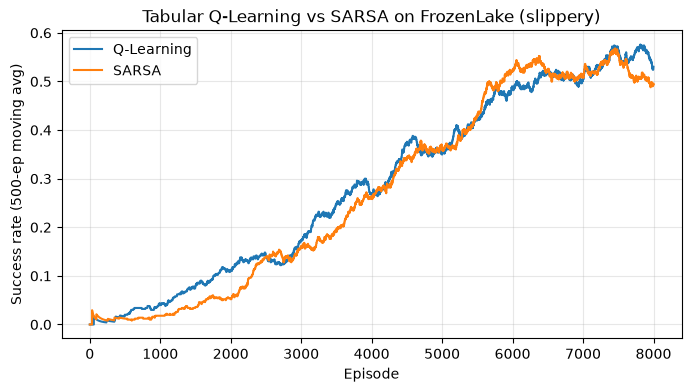

解读：两者都能学到 ~55-70% 成功率（随种子波动；打滑随机性决定了上限不在 100%）；
收敛速度和渐近水平的差异与超参、随机性有关—— FrozenLake 太小，
SARSA 的'保守'特性在 CliffWalking 这类有'危险捷径'的环境里才会充分体现。


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(8, 4))
for name, succ in [("Q-Learning", succ_ql), ("SARSA", succ_sa)]:
    smooth = pd.Series(succ).rolling(500, min_periods=1).mean()
    ax.plot(smooth, label=name)
ax.set_xlabel("Episode"); ax.set_ylabel("Success rate (500-ep moving avg)")
ax.set_title("Tabular Q-Learning vs SARSA on FrozenLake (slippery)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print("解读：两者都能学到 ~55-70% 成功率（随种子波动；打滑随机性决定了上限不在 100%）；")
print("收敛速度和渐近水平的差异与超参、随机性有关—— FrozenLake 太小，")
print("SARSA 的'保守'特性在 CliffWalking 这类有'危险捷径'的环境里才会充分体现。")

## 6. 看看学到的策略长什么样

把 Q 表的 $\arg\max$ 画成箭头地图，人工检查是否合理（避开 H、奔向 G）：

In [5]:
ARROWS = ["←", "↓", "→", "↑"]  # FrozenLake 动作 0-3

def print_policy(Q, desc):
    desc = desc.astype(str)
    for i, row in enumerate(desc):
        out = []
        for j, cell in enumerate(row):
            if cell in "HG":
                out.append(cell)
            else:
                out.append(ARROWS[int(np.argmax(Q[i * 4 + j]))])
        print(" ".join(out))

env = gym.make("FrozenLake-v1", is_slippery=True)
print("Q-Learning 学到的策略：")
print_policy(Q_ql, env.unwrapped.desc)
env.close()

Q-Learning 学到的策略：
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G


## 7. 超参数速查表

| 超参 | 作用 | 典型现象 |
|---|---|---|
| $\alpha$ 学习率 | 更新步长 | 太大会震荡不收敛；太小学得慢 |
| $\gamma$ 折扣 | 远见程度 | 稀疏奖励任务太小会「看不到」远处的奖励 |
| $\varepsilon$ 及衰减 | 探索力度 | 不衰减则成功率曲线天花板更低（总在乱跑） |
| Q 表初始化 | 乐观初始化可鼓励探索 | 全 0 初始化在稀疏奖励下冷启动慢 |

---

## ✏️ 练习

**练习 1（★，10 分钟）——关掉打滑**
把环境换成 `is_slippery=False` 重新训练 Q-Learning（5000 回合即可）。
**交付物**：成功率曲线 + 一句话解释为什么确定性环境下能到 ~100%。

**练习 2（★★，20 分钟）——ε 衰减的消融**
在 slippery 环境上对比两组：固定 $\varepsilon=0.1$（不衰减）vs 本 notebook 的指数衰减。
**交付物**：两条曲线画在同一张图 + 两句话结论（训练后期谁的评估成功率高？为什么？）。

**练习 3（★★，25 分钟）——策略可视化检查**
用 `print_policy` 打印你练 1 中确定性环境学到的策略箭头图，人工检查每个 F 格的箭头
是否都指向一条通向 G 的安全路径（若某格指向 H，解释为什么训练没能修正它）。
**交付物**：箭头图 + 检查结论。

**练习 4（★★，25 分钟）——学习率敏感性**
固定其他超参，在 slippery 环境上扫 $\alpha \in \{0.01, 0.1, 0.5\}$ 三组 Q-Learning 实验。
**交付物**：三条曲线 + 两句话说明 $\alpha$ 过大时的现象与原因。

**练习 5（★★★，35 分钟）——Expected SARSA（选做）**
把 SARSA 的 TD 目标改为对下一动作取**期望**：
$\mathbb{E}_\pi[Q(S_{t+1}, \cdot)] = (1-\varepsilon)\max_a Q + \frac{\varepsilon}{|\mathcal{A}|}\sum_a Q(s',a)$。
对比普通 SARSA 的曲线方差。
**交付物**：实现代码 + 对比图 + 一句「Expected SARSA 为何方差更小」的解释。

---

<details>
<summary>参考答案（做完再点开）</summary>

**练习 1**：确定性环境中每条「安全路线」的回报可重复获得，Q 值会稳定收敛到真实回报，
贪心策略沿唯一安全路径 6 步到 G，成功率 ~100%。打滑时即是最优策略也可能被滑进洞里，故天花板更低。

**练习 2**：固定 $\varepsilon=0.1$ 的曲线后期天花板明显更低——
**训练成功率里混着 10% 的随机动作**。衰减组后期几乎纯贪心，能逼近策略本身的水平。
教训：对比算法时要用「纯贪心评估」而非训练曲线，否则评估被探索率污染。

**练习 3**：确定性环境下学到的策略应呈现「绕 H 而行」的流向图；
个别从未访问过的格子（如被 H 包围的孤立 F）箭头可能无意义——
因为这些 (s,a) 的 Q 值从未被更新过，argmax 是初始 0 的平局结果。

**练习 4**：$\alpha=0.5$ 时曲线噪声大、成功率反而更低：单步采样（尤其打滑环境的随机转移）
噪声被大步长直接灌进 Q 值，旧的正确估计被反复覆盖。$\alpha$ 太小则 8000 回合内还没收敛。
随机环境下理论要求 $\sum\alpha=\infty,\sum\alpha^2<\infty$（逐渐衰减的学习率）保证收敛。

**练习 5**：Expected SARSA 用期望代替单次采样 $a'$，消除了「$a'$ 恰好是探索动作」带来的采样噪声，
因此更新方向更稳定、曲线方差更小；它仍可按 $\pi$ 取期望（on-policy），
若按贪心策略取期望则退化为 Q-Learning。

</details>

---

## 延伸阅读

- Sutton & Barto 第 6 章（TD Learning）—— 本周内容的权威出处，CliffWalking 例子在此。
- [《动手学强化学习》第 3–4 章](https://hrl.boyuai.com/) —— 中文讲解 + 可运行代码。
- [Gymnasium FrozenLake 环境文档](https://gymnasium.farama.org/environments/toy_text/frozen_lake/)
- [David Silver UCL 课程 Lecture 4–5](https://www.davidstarsilver.uk/teaching/)（Model-free prediction & control）
- 原始论文：Watkins (1989) Q-Learning 博士论文；Rummery & Niranjan (1994) SARSA——可在 Sutton & Barto 书目注释中找到线索。